<div style="text-align: center;">
    <h1 style="
        background: linear-gradient(135deg, #470000ff, #802323ff);
        color: white; 
        padding: 15px 30px; 
        border-radius: 500px; 
        font-family: 'Segoe UI', Arial, sans-serif; 
        box-shadow: 0 4px 15px rgba(0,0,0,0.3);
        display: inline-block;
    ">
       House Price Prediction using Linear Regression
    </h1>
</div>


<h4 style="color:#d20404c1">1. Imports and setup for data analysis (NumPy, Pandas), visualization (Matplotlib, Seaborn), and an ML workflow with scikit-learn (train_test_split, StandardScaler, LinearRegression) plus evaluation metrics (R², MAE, MSE, classification_report).</h4>

In [616]:
import numpy as np
import pandas as pd
pd.set_option("display.max_columns",200)
import matplotlib.pyplot as plt
plt.style.use("ggplot")
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score,classification_report,mean_absolute_error,mean_squared_error
from sklearn.model_selection import train_test_split

<h4 style="color:#d20404c1">2. Loading the housing dataset (housing.csv) from the local path into a Pandas DataFrame (<code>house_data</code>) for downstream EDA and modeling.</h4>


In [617]:
house_data=pd.read_csv(r"C:\Users\Rammah\OneDrive\Desktop\اجازه ان شاء الله\GTC-ML-internship\Week 2 Day 01\Task\Data\housing.csv")

<h4 style="color:#d20404c1">3. Previewing the first 5 rows of the DataFrame with <code>house_data.head()</code> to confirm successful load, inspect columns, and quickly spot obvious issues (missing values/outliers).</h4>

In [618]:
house_data.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


<h4 style="color:#d20404c1">4. Inspecting the DataFrame schema with <code>house_data.info()</code> to view column dtypes, non-null counts, and memory usage—useful for spotting missing data and planning preprocessing.</h4>

In [619]:
house_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


<h4 style="color:#d20404c1">5. Generating summary statistics with <code>house_data.describe()</code> to inspect central tendency (mean), dispersion (std, quartiles), ranges (min/max), and flag outliers/skewness in numeric features.</h4>

In [620]:
house_data.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


<h4 style="color:#d20404c1">13. Auditing remaining missing values and engineering ratio features—<code>rooms_per_household</code>, <code>bedrooms_per_room</code>, and <code>population_per_household</code>—to enrich the feature set with household density and room-mix signals.</h4>


In [621]:
house_data.isna().sum()
house_data["rooms_per_household"] = house_data["total_rooms"] / house_data["households"]
house_data["bedrooms_per_room"]   = house_data["total_bedrooms"] / house_data["total_rooms"]
house_data["population_per_household"] = house_data["population"] / house_data["households"]

<h4 style="color:#d20404c1">7. Exploring the categorical distribution of <code>ocean_proximity</code> with <code>value_counts()</code> to gauge class balance, spot rare categories, and inform encoding choices or stratified splits.</h4>

In [622]:
house_data['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

<h4 style="color:#d20404c1">8. Visualizing the distribution of the categorical feature <code>ocean_proximity</code> with a percentage-labeled pie chart (Set3 palette, fixed figure size, defined start angle) to assess class balance.</h4>


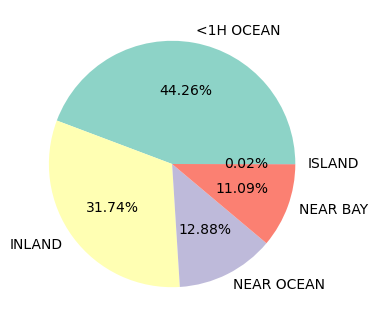

In [623]:
plt.figure(figsize=(7,4))
plt.pie(house_data['ocean_proximity'].value_counts(),labels=house_data['ocean_proximity'].value_counts().index,autopct='%1.2f%%',colors=plt.cm.Set3.colors,startangle=0)
plt.show()

<h4 style="color:#d20404c1">9. One-hot encoding the categorical feature <code>ocean_proximity</code> (with <code>drop_first=True</code>) to create numeric, model-ready indicators while avoiding multicollinearity.</h4>

In [624]:
house_data = pd.get_dummies(house_data, columns=['ocean_proximity'], drop_first=True)

<h4 style="color:#d20404c1">10. Handling missing values by dropping rows with NaN in <code>total_bedrooms</code>, then re-auditing dataset-wide nulls with <code>isna().sum()</code> to verify cleanliness.</h4>

In [625]:
house_data = house_data.dropna(subset=['total_bedrooms'])
house_data.isna().sum()

longitude                     0
latitude                      0
housing_median_age            0
total_rooms                   0
total_bedrooms                0
population                    0
households                    0
median_income                 0
median_house_value            0
rooms_per_household           0
bedrooms_per_room             0
population_per_household      0
ocean_proximity_INLAND        0
ocean_proximity_ISLAND        0
ocean_proximity_NEAR BAY      0
ocean_proximity_NEAR OCEAN    0
dtype: int64

<h4 style="color:#d20404c1">11. Plotting histograms for all numeric features (figure size 15×10, orange color) to inspect distributions, skewness, and outliers—informing transformations, binning, and scaling decisions.</h4>

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>],
       [<Axes: title={'center': 'rooms_per_household'}>,
        <Axes: title={'center': 'bedrooms_per_room'}>,
        <Axes: title={'center': 'population_per_household'}>]],
      dtype=object)

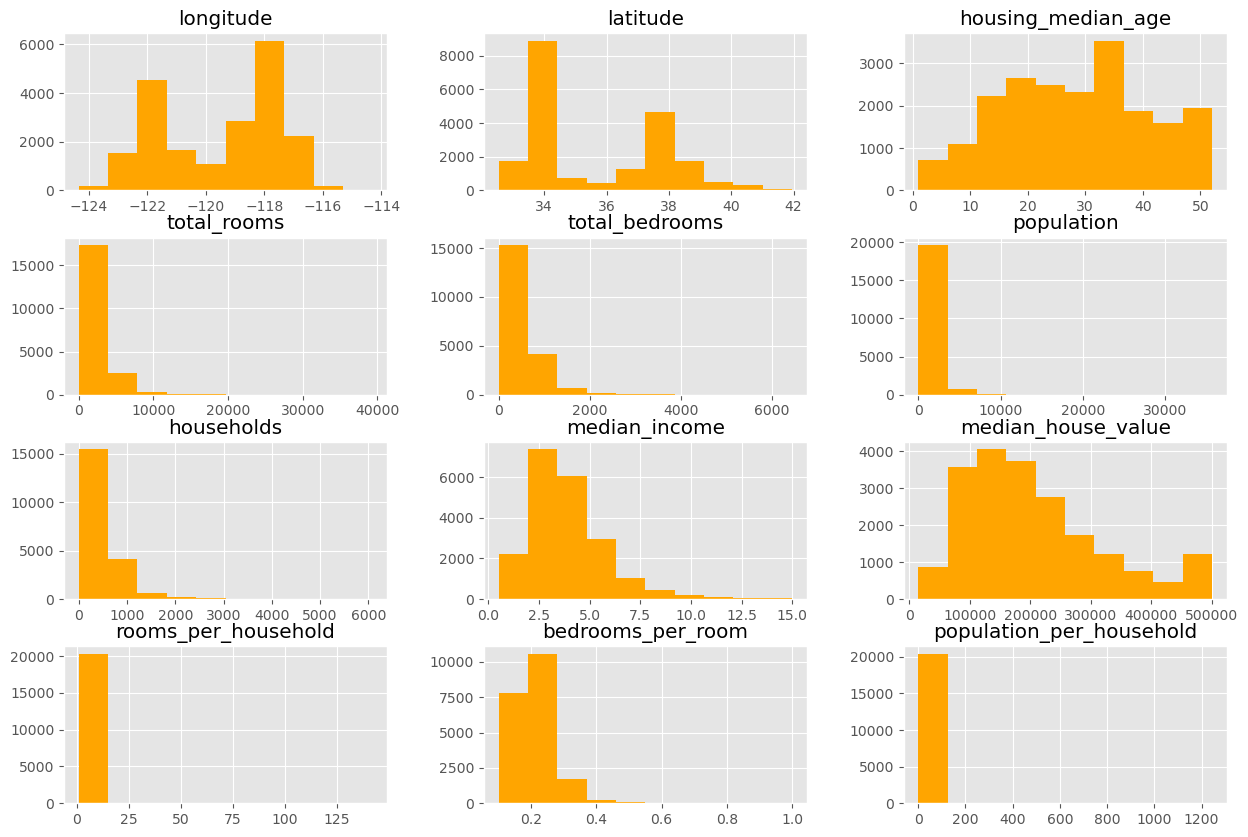

In [626]:
house_data.hist(figsize=(15,10),color="orange")

<h4 style="color:#d20404c1">12. Pairwise EDA with Seaborn’s <code>pairplot</code> to inspect bivariate relationships and marginal distributions across features (note: can be heavy after one-hot; consider subsetting numeric columns or sampling).</h4>

<Figure size 1500x500 with 0 Axes>

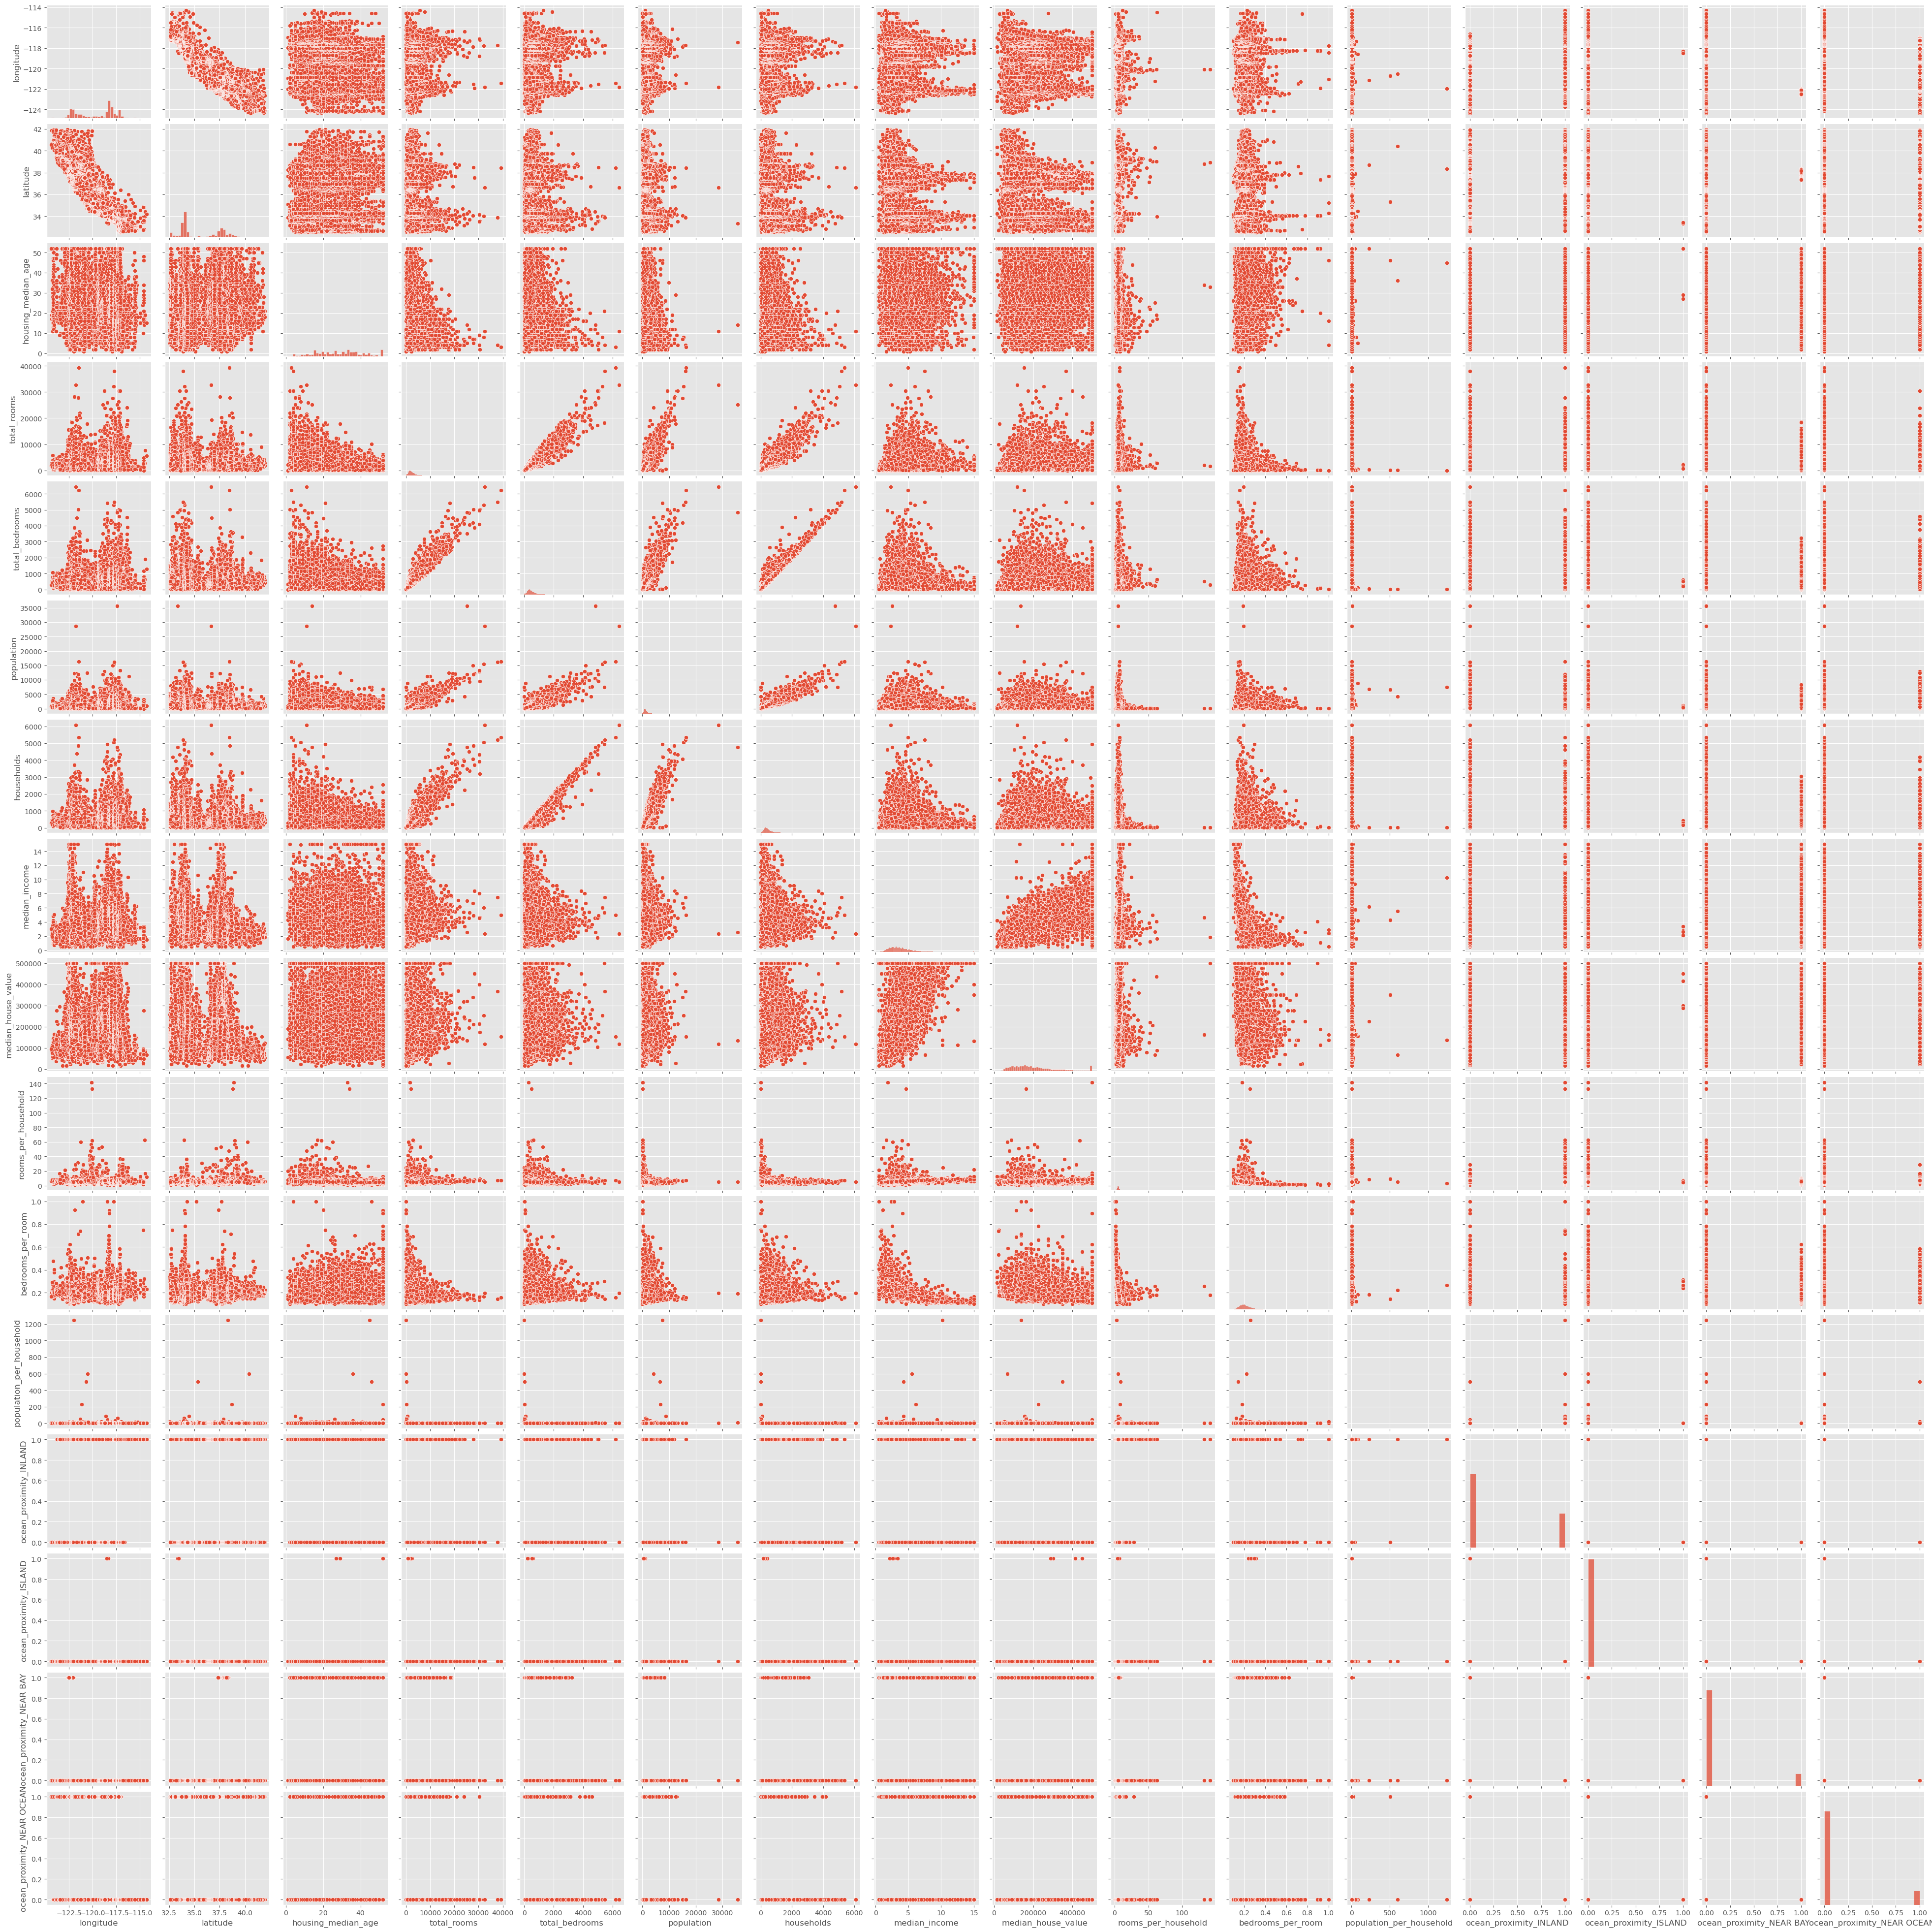

In [627]:
plt.figure(figsize=(15,5))
sns.pairplot(house_data)
plt.show()

<h4 style="color:#d20404c1">13. Removing the raw bedroom count (<code>total_bedrooms</code>) after creating ratio features to reduce multicollinearity and keep only the most informative signals.</h4>


In [628]:
house_datacopy=house_data.drop(columns=['total_bedrooms'],axis=1)

<h4 style="color:#d20404c1">14. Correlation analysis via Seaborn heatmap (numeric features only) with annotations and a diverging colormap to spot multicollinearity and strongest predictors of <code>median_house_value</code>.</h4>

<Axes: >

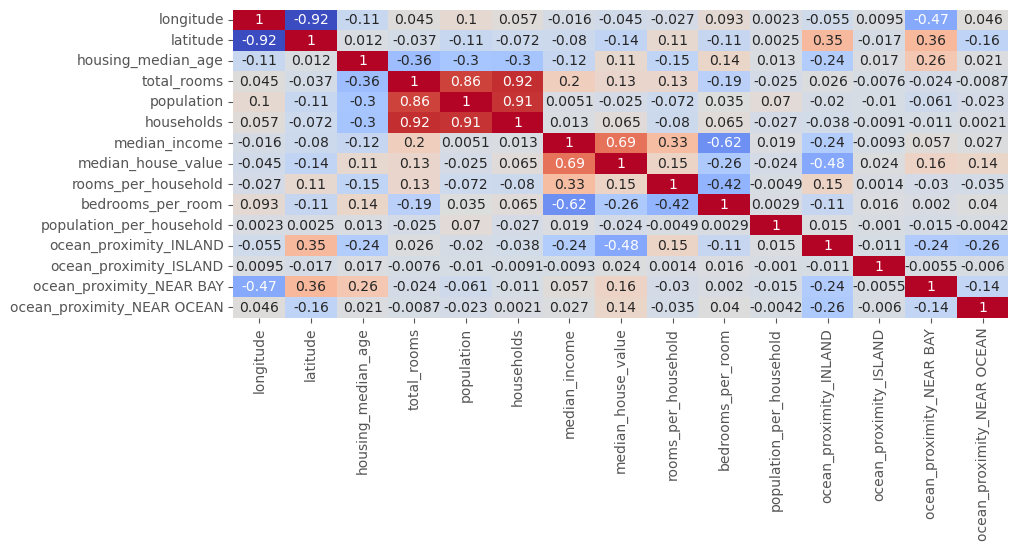

In [629]:
plt.figure(figsize=(10,4))
sns.heatmap(house_datacopy.corr(),annot=True,color='darkblue',cbar=False,cmap="coolwarm")

<h4 style="color:#d20404c1">15. Creating features (X) and target (y = <code>median_house_value</code>), then performing an 80/20 train–test split (<code>random_state=42</code>) for unbiased evaluation.</h4>

In [630]:
X=house_data.drop(columns=['median_house_value'],axis=1)
Y=house_data['median_house_value']
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

<h4 style="color:#d20404c1">16. Checking the shapes of the training and test feature sets (<code>X_train.shape</code>, <code>X_test.shape</code>) to verify the 80/20 split and confirm identical feature counts across both sets.</h4>

In [631]:
X_train.shape,X_test.shape

((16346, 15), (4087, 15))

<h4 style="color:#d20404c1">17. Standardizing features with StandardScaler —> fit on the training data, then transform the test set to prevent data leakage.</h4>

In [632]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)

X_test=scaler.fit_transform(X_test)

<h4 style="color:#d20404c1">18. Training the Linear Regression model on the scaled training set (<code>fit</code>) to learn coefficients and intercept as a baseline regressor.</h4>

In [633]:
Model=LinearRegression()
Model.fit(X_train,Y_train)

LinearRegression()

<h4 style="color:#d20404c1">19. Re-auditing missing values with <code>house_data.isna().sum()</code> as a post-preprocessing sanity check to confirm no nulls remain before evaluation and prediction.</h4>

In [634]:
house_data.isna().sum()

longitude                     0
latitude                      0
housing_median_age            0
total_rooms                   0
total_bedrooms                0
population                    0
households                    0
median_income                 0
median_house_value            0
rooms_per_household           0
bedrooms_per_room             0
population_per_household      0
ocean_proximity_INLAND        0
ocean_proximity_ISLAND        0
ocean_proximity_NEAR BAY      0
ocean_proximity_NEAR OCEAN    0
dtype: int64

<h4 style="color:#d20404c1">20. Evaluating the model on the test set — printing R², MAE, and MSE (note: use <code>squared=False</code> in <code>mean_squared_error</code> to get true RMSE).</h4>

In [635]:
print("R2:", r2_score(Y_test,Model.predict(X_test)))
print("MAE:", mean_absolute_error(Y_test,Model.predict(X_test)))
print("RMSE:", mean_squared_error(Y_test,Model.predict(X_test)))

R2: 0.6522246430674669
MAE: 49923.57685458744
RMSE: 4755890878.985003
